In [2]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt

# Exercise 1: Importance Sampling (1D Adaptive Grid)
+	Define a function named **Vegas_Simple(lower, upper, func, n_points, bins, iterations)** to compute a one-dimensional integral using the Importance Sampling method. The regions of importance are defined by the magnitude of the function.

	Hint:

	**Step 1**: Divide the integration range into a specified number of equal-width bins. (Note: For the first iteration, distribute the n_points uniformly across all bins).

	**Step 2**: For each iteration:
	*	Sample random points within each bin and calculate the bin's integral ($I_{bi}$).
	*	Update the number of points for the next iteration $\sim$ the bin's contribution to the total

	$w_{bin_i} = |\dfrac{I_{bi}}{\sum{I_{bj}}} |$.

	Ensure every bin receives at least 2 points to maintain the grid.

	**Step 3**: Return the final estimate in the form $\bar{I} \pm \sigma_{\bar{I}}$, where 
	$\bar{I}$ is the mean of all iterations and 
	$\sigma_{\bar{I}}$ is the standard error calculated as follow:
	+	For every bin $b_i$, the variance is $(\sigma_{\bar{b_i}})^2 = \dfrac{\sigma_{b_i}^2}{n_i}, n_i$ is the number of points in that bin 
	+	The variance of the total integral for a single iteration $j$: $\sigma_{\bar{I_j}}^2 = \sum_{\text{all bins}} \sigma_{\bar{b_i}}^2$
	+	The standard error after N iterations is $\sigma_{\bar{I}} = \frac{1}{N} * \sqrt{\sum\sigma_{\bar{I_j}}^2} $

+	Using your function to compute the following integral:
	$$ I = \int_{0}^{2 \pi} \sin^2(x)dx$$
+	Verify the result by calculating the absolute error: $|\bar{I} - \pi|$
<!-- +	Analyze the convergence: Change the number of points and plot the absolute error and the Standard error (std) as a function of the number of points using log-log scale. Discussion: How do these errors behave as the number of points increases? -->
+	Compare the convergence of the Vegas simple method and the uniform method (using your previous MC_1dim function) by plotting the standard error of both approaches on a log-log scale. Which method has a smaller error? Ensure both methods have the same total number of points (total points = iterations x n_points for Vegas).
+	Modify the Vegas_Simple function so that it returns the results and the total number of random points sampled in each bin across all iterations. Plot the distribution of these points after several iteration steps to observe how the sampling behavior evolves.

In [133]:
def sin_squared(x):
    return math.sin(x) ** 2

def vegas_simple(lower, upper, func, points, bins, iterations):
    bin_ranges = []
    bin_points = []
    bin_weights = [1.0 / bins] * bins
    bin_width = (upper - lower) / bins
    iteration_results = []
    iteration_points = []

    # Calculate bin ranges
    for i in range(bins):
        bin_ranges.append((lower + (i * bin_width), lower + ((i + 1) * bin_width)))

    # Main Vegas loop
    for iteration in range(iterations):

        # Calculate the number of points for each bin based on the current weights
        bin_points = [max(int(points * bin_weights[i]), 2) for i in range(bins)]

        # Store the number of points for iterations
        iteration_points.append(bin_points)

        bin_sums = [0] * bins
        bin_sums_squared = [0] * bins
        bin_integrals = [0] * bins
        bin_variances = [0] * bins

        print(f"Iteration {iteration + 1}: Bin weights: {bin_weights} Bin points: {bin_points} Sum: {sum(bin_points)}")

        # Monte Carlo sampling for each bin
        for b in range(bins):
            for _ in range(bin_points[b]):
                x = random.uniform(bin_ranges[b][0], bin_ranges[b][1])
                val = func(x)
                bin_sums[b] += val
                bin_sums_squared[b] += val ** 2

            print(f"\tBin {b + 1}: Sum: {bin_sums[b]}")

        # Calculate integrals and variances for each bin
        for b in range(bins):
            mean_f = bin_sums[b] / bin_points[b]
            mean_f_sq = bin_sums_squared[b] / bin_points[b]
            var_f = abs(mean_f_sq - (mean_f ** 2))
            
            bin_integrals[b] = mean_f * bin_width
            bin_variances[b] = (bin_width ** 2) * (var_f / bin_points[b])

            print(f"\tBin {b + 1}: Integral: {bin_integrals[b]}, Variance: {bin_variances[b]}")

        # Calculate total integral and variance for the iteration
        bin_total_integral = sum(bin_integrals)
        bin_total_variance = sum(bin_variances)
        iteration_results.append((bin_total_integral, bin_total_variance))

        print(f"\n\tTotal integral: {bin_total_integral}, Total variance: {bin_total_variance}\n")

        # Update bin weights for the next iteration
        for bin in range(bins):
            bin_weights[bin] = abs(bin_integrals[bin] / bin_total_integral)

    # Final results after all iterations
    iter_total_integral = sum(integral for integral, _ in iteration_results) / iterations
    iter_total_variances = sum(variance for _, variance in iteration_results)
    iter_total_stderror = (1 / iterations) * math.sqrt(iter_total_variances)

    print(f"\nFinal integral: {iter_total_integral}")
    print(f"Final standard error: {iter_total_stderror}")
    print(f"Final absolute error: {abs(iter_total_integral - math.pi)}")

    return iter_total_integral, iter_total_stderror, iteration_points, bin_ranges


# Example parameters
lower = 0
upper = 2 * math.pi
func = sin_squared
total_points = 10_000
bins = 5
iterations = 3

integral, error, history_points, bin_ranges = vegas_simple(lower, upper, func, total_points, bins, iterations)

Iteration 1: Bin weights: [0.2, 0.2, 0.2, 0.2, 0.2] Bin points: [2000, 2000, 2000, 2000, 2000] Sum: 10000
	Bin 1: Sum: 781.5469377868837
	Bin 2: Sum: 1610.720697548624
	Bin 3: Sum: 232.00566670333134
	Bin 4: Sum: 1613.2686000609183
	Bin 5: Sum: 751.62771541217
	Bin 1: Integral: 0.4910604236373746, Variance: 6.968921340825491e-05
	Bin 2: Integral: 1.0120456620807567, Variance: 3.198880863660821e-05
	Bin 3: Integral: 0.14577345962127755, Variance: 8.089559102398105e-06
	Bin 4: Integral: 1.013646556443694, Variance: 3.234357284748076e-05
	Bin 5: Integral: 0.47226162179467057, Variance: 6.98572131284938e-05

	Total integral: 3.1347877235777735, Total variance: 0.0002119683671232358

Iteration 2: Bin weights: [0.156648700626185, 0.32284344310424185, 0.04650185992654853, 0.32335412979313516, 0.1506518665498895] Bin points: [1566, 3228, 465, 3233, 1506] Sum: 9998
	Bin 1: Sum: 601.0395389336347
	Bin 2: Sum: 2599.9279620635543
	Bin 3: Sum: 54.4467570734277
	Bin 4: Sum: 2597.391736075224
	Bin 5:

In [108]:
# MC_1dim from previous problem set
def MC_1dim(lower, upper, func, points):
    if points <= 1:
        raise ValueError("Number of points must be greater than 1.")

    count = 0; mean_f = 0.0; M2 = 0.0
    
    for _ in range(points):
        x = random.uniform(lower, upper)
        val = func(x)

        count += 1
        delta_1 = val - mean_f
        mean_f += delta_1 / count
        delta_2 = val - mean_f
        M2 += delta_1 * delta_2
    
    integral_f = (upper - lower) * mean_f
    variance_f = M2 / (points - 1)
    std_dev_f = math.sqrt(variance_f)
    std_error_f = (upper - lower) * std_dev_f / math.sqrt(points)

    return integral_f, std_error_f

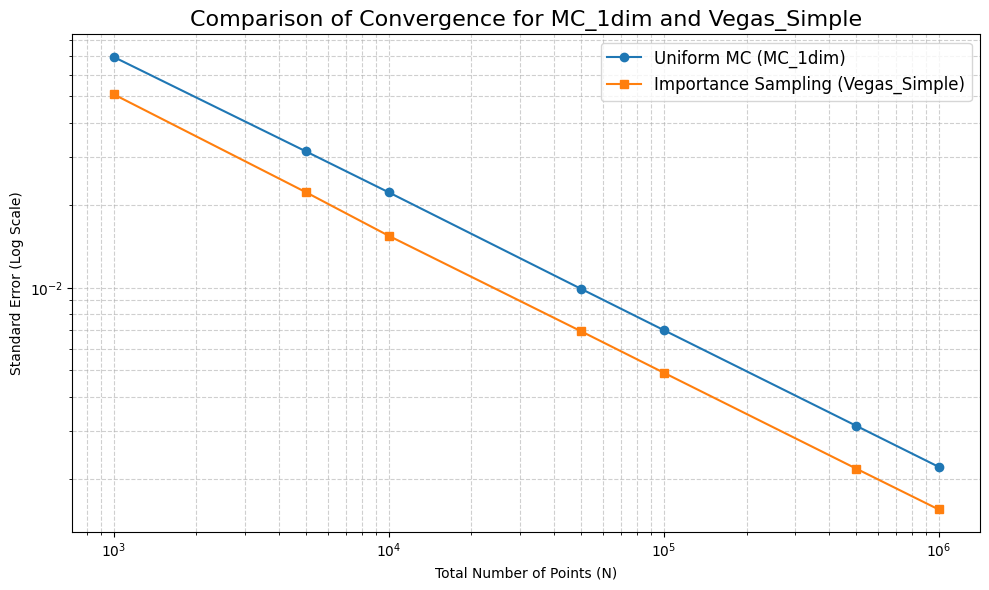

In [119]:
# Comparison of convergence for MC_1dim and Vegas_Simple

total_points_list = [1000, 5000, 10000, 50000, 100000, 500000, 1000000]
    
mc_errors = []
vegas_errors = []
        
for total_points in total_points_list:
        
    # MC_1dim
    _, mc_err = MC_1dim(0, 2 * math.pi, sin_squared, total_points)
    mc_errors.append(mc_err)
        
    # Vegas_Simple
    points_per_iter = total_points // iterations
    _, vegas_err, _, _ = vegas_simple(0, 2 * math.pi, sin_squared, points_per_iter, bins, iterations)
    vegas_errors.append(vegas_err)


plt.figure(figsize=(10, 6))
plt.loglog(total_points_list, mc_errors, '-o', label='Uniform MC (MC_1dim)')
plt.loglog(total_points_list, vegas_errors, '-s', label='Importance Sampling (Vegas_Simple)')
    
plt.title('Comparison of Convergence for MC_1dim and Vegas_Simple', fontsize=16)
plt.xlabel('Total Number of Points (N)')
plt.ylabel('Standard Error (Log Scale)')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(fontsize=12)
    
plt.tight_layout()
plt.show()

Advantage of Importance Sampling comes from increased sampling where function has significant value. In classic Monte Carlo we lose some points to calculate value in a places where f(x) is close to 0. Vegas Importance Sampling gets consistent better results not dependent of number of points.

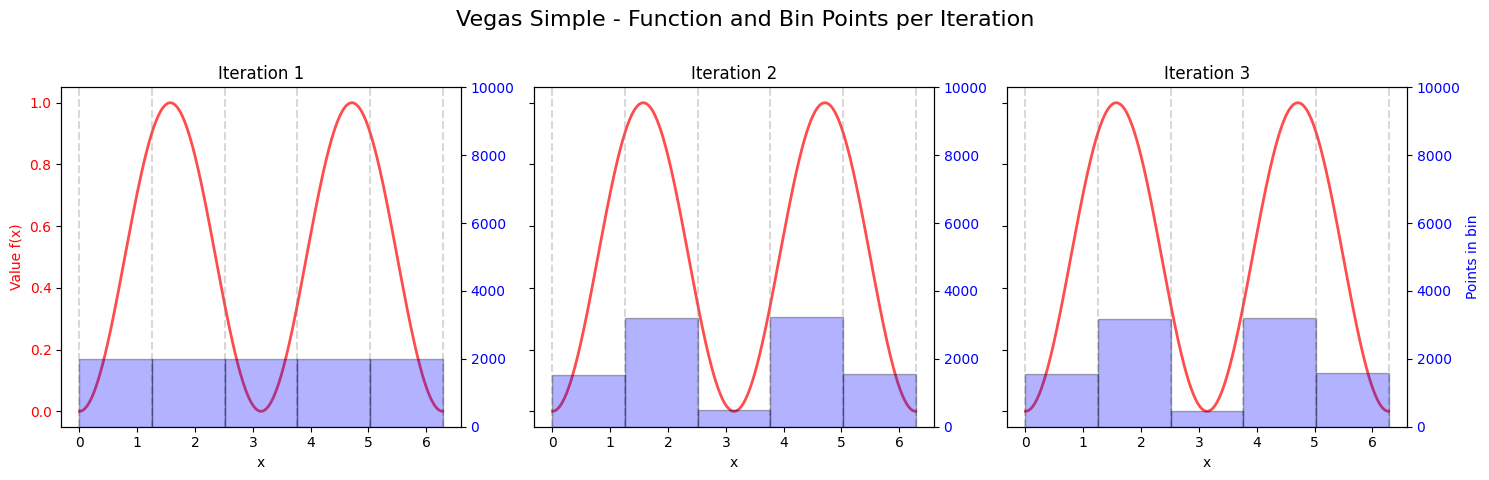

In [ ]:
# Vegas Simple - points and bins visualization

cols = 3
rows = math.ceil(iterations / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows), sharey=True)

if iterations > 1:
    axes = axes.flatten()
else:
    axes = [axes]
    
x_vals = np.linspace(lower, upper, 1000)
y_vals = [func(x) for x in x_vals]
bin_width = (upper - lower) / bins

for i in range(rows * cols):

    ax = axes[i]

    if i < iterations:

        # Main plot - function f(x)
        ax.plot(x_vals, y_vals, 'r-', label='f(x)', linewidth=2, alpha=0.7)
        ax.set_title(f'Iteration {i + 1}')
        ax.set_xlabel('x')
        if i % cols == 0:
            ax.set_ylabel('Value f(x)', color='red')
        ax.tick_params(axis='y', labelcolor='red')
            
        # Secondary plot - points in bins
        ax2 = ax.twinx()
        bin_centers = [0.5 * (bin_ranges[b][0] + bin_ranges[b][1]) for b in range(bins)]
        ax2.bar(bin_centers, history_points[i], width=bin_width, alpha=0.3, 
                color='blue', edgecolor='black')
        
        if (i + 1) % cols == 0 or i == iterations - 1:
            ax2.set_ylabel('Points in bin', color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')
        ax2.set_ylim(0, total_points)
            
        # Vertical lines for bin boundaries
        for b_range in bin_ranges:
            ax.axvline(b_range[0], color='gray', linestyle='--', alpha=0.3)
        ax.axvline(bin_ranges[-1][1], color='gray', linestyle='--', alpha=0.3)
    else:
        ax.axis('off')

plt.suptitle('Vegas Simple - Function and Bin Points per Iteration', fontsize=16)
fig.tight_layout(rect=(0, 0.03, 1, 0.97))
plt.show()

# Exercise 2: Generate different distributions
Use the uniform distribution to generate an exponential distribution $p(x) = e^{-x}$ and a Gaussian distribution (using the formular in the lecture). Plot the histogram to check the results.

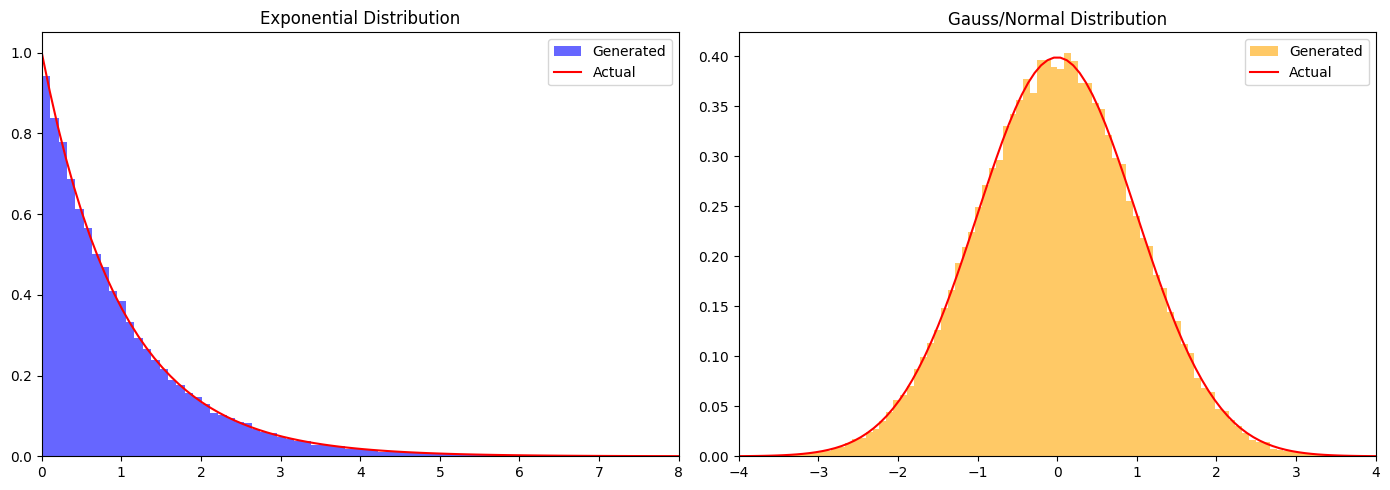

In [106]:
N = 100_000

# Base random numbers with Uniform Distribution (u ~ U(0,1))
u1 = np.random.uniform(0, 1, N)
u2 = np.random.uniform(0, 1, N)

# Exponential Distribution with Inverse Transform (x = -ln(u))
x_exp = -np.log(u1)

# Gauss Distribution with Box-Muller (z0 = sqrt(-2*ln(u1)) * cos(2*pi*u2), z1 = sqrt(-2*ln(u1)) * sin(2*pi*u2))
x_gauss = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Exponential Distribution
ax1.hist(x_exp, bins=100, density=True, alpha=0.6, color='blue', label='Generated')

x_vals_exp = np.linspace(0, 10, 100)
y_vals_exp = np.exp(-x_vals_exp)
ax1.plot(x_vals_exp, y_vals_exp, 'r-', label='Actual')

ax1.set_title('Exponential Distribution')
ax1.set_xlim(0, 8)
ax1.legend()

# Plot 2: Gauss Distribution
ax2.hist(x_gauss, bins=100, density=True, alpha=0.6, color='orange', label='Generated')

x_vals_gauss = np.linspace(-4, 4, 100)
y_vals_gauss = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x_vals_gauss**2)
ax2.plot(x_vals_gauss, y_vals_gauss, 'r-', label='Actual')

ax2.set_title('Gauss/Normal Distribution')
ax2.set_xlim(-4, 4)
ax2.legend()

plt.tight_layout()
plt.show()